# Análise Exploratória de Dados (EDA) Exaustiva - Alfabetização e Desempenho

Neste notebook, faremos uma exploração profunda e exaustiva das bases `fato_alfabetizacao`, `fato_desempenho` e `dim_municipio`. O objetivo é extrair o máximo de insights sobre os fatores que afetam a alfabetização no Brasil, padrões regionais, análise no nível do município e do aluno.


## 1. Configuração e Instalação de Pacotes


In [1]:
%pip install python-dotenv databricks-sql-connector matplotlib seaborn scipy pandas numpy


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Conexão e Extração de Dados


In [2]:
import os
import dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from databricks import sql
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# Variáveis de ambiente
dotenv.load_dotenv()
access_token = os.getenv("SQL_DATABRICKS_ACCESS_TOKEN")
server_hostname = os.getenv("SERVER_HOSTNAME")
warehouse_id = os.getenv("WAREHOUSE_ID")

# Tabelas
dim_municipio = 'workspace.gold.tc02_dim_municipio'
fato_alfabetizacao = 'workspace.gold.tc02_fato_alfabetizacao_consolidada'
fato_desempenho = 'workspace.gold.tc02_fato_desempenho'

def carregar_tabela(nome_tabela: str, where: str = "") -> pd.DataFrame:
    connection = sql.connect(
        server_hostname=server_hostname,
        http_path=f"/sql/1.0/warehouses/{warehouse_id}",
        access_token=access_token,
    )
    cursor = connection.cursor()
    cursor.execute(f"SELECT * FROM {nome_tabela} {where}")
    resultado = cursor.fetchall()
    cursor.close()
    connection.close()
    return pd.DataFrame([row.asDict() for row in resultado])

print("Extraindo Dados...")
df_dim_municipio = carregar_tabela(dim_municipio)
df_alfabetizacao = carregar_tabela(fato_alfabetizacao)
df_desempenho = carregar_tabela(fato_desempenho)
print("Dados carregados com sucesso!")


Extraindo Dados...


[WARN] pyarrow is not installed by default since databricks-sql-connector 4.0.0,any arrow specific api (e.g. fetchmany_arrow) and cloud fetch will be disabled.If you need these features, please run pip install pyarrow or pip install databricks-sql-connector[pyarrow] to install


Dados carregados com sucesso!


## 3. Qualidade de Dados e Enriquecimento

Vamos checar valores nulos, duplicados e criar as macros regiões do Brasil.


In [3]:
# Verificando Valores Nulos
print("Nulos em Alfabetização:\n", df_alfabetizacao.isnull().sum(), "\n")
print("Nulos em Desempenho:\n", df_desempenho.isnull().sum(), "\n")

# Juntando Alfabetização com Municípios
df_alfa_mun = df_alfabetizacao.merge(df_dim_municipio[['sk_municipio', 'id_municipio', 'sigla_uf', 'nome_estado']], on='sk_municipio', how='left')

# Mapeando Regiões
regioes = {
    'Norte': ['AC', 'AP', 'AM', 'PA', 'RO', 'RR', 'TO'],
    'Nordeste': ['AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE'],
    'Centro-Oeste': ['DF', 'GO', 'MT', 'MS'],
    'Sudeste': ['ES', 'MG', 'RJ', 'SP'],
    'Sul': ['PR', 'RS', 'SC']
}
uf_para_regiao = {uf: regiao for regiao, ufs in regioes.items() for uf in ufs}
df_alfa_mun['regiao'] = df_alfa_mun['sigla_uf'].map(uf_para_regiao)

# Juntando Desempenho com Municípios para análises detalhadas
df_desemp_mun = df_desempenho.merge(df_dim_municipio[['sk_municipio', 'id_municipio', 'sigla_uf', 'nome_estado']], on='sk_municipio', how='left')
df_desemp_mun['regiao'] = df_desemp_mun['sigla_uf'].map(uf_para_regiao)

display(df_alfa_mun.head(3))


Nulos em Alfabetização:
 sk_municipio                            0
ano                                     0
rede                                    0
total_alunos_avaliados                  0
media_proficiencia_alunos               0
taxa_alfabetizacao_real_escala_10       0
meta_alfabetizacao_projetada         4799
desvio_da_meta                       4799
meta_percentual_participacao            0
nivel_alfabetizacao                     0
_data_processamento_gold                0
dtype: int64 

Nulos em Desempenho:
 id_aluno                    0
ano                         0
sk_municipio                0
id_escola                   0
caderno                     0
serie                       0
rede                        0
presenca                    0
preenchimento_caderno       0
alfabetizado                0
proficiencia                0
peso_prova_portugues        0
_data_processamento_gold    0
dtype: int64 



,sk_municipio,ano,rede,total_alunos_avaliados,media_proficiencia_alunos,taxa_alfabetizacao_real_escala_10,meta_alfabetizacao_projetada,desvio_da_meta,meta_percentual_participacao,nivel_alfabetizacao,_data_processamento_gold,id_municipio,sigla_uf,nome_estado,regiao
0,5922877142448228416,2024,MUNICIPAL,5449,755.34,6.94,63.87,-56.93,89.28,3,2026-08-21 05:02:41.179017,5201405,GO,Goiás,Centro-Oeste
1,2479692279129808206,2024,MUNICIPAL,179,748.40,6.37,60.56,-54.19,97.28,3,2026-08-21 05:02:41.179017,2603108,PE,Pernambuco,Nordeste
2,4386444981971766132,2024,MUNICIPAL,864,754.71,7.20,74.42,-67.22,85.97,4,2026-08-21 05:02:41.179017,4122404,PR,Paraná,Sul


## 4. Análise Univariada (Distribuição das Variáveis)
Vamos entender a distribuição de cada variável numérica importante na base de Alfabetização.


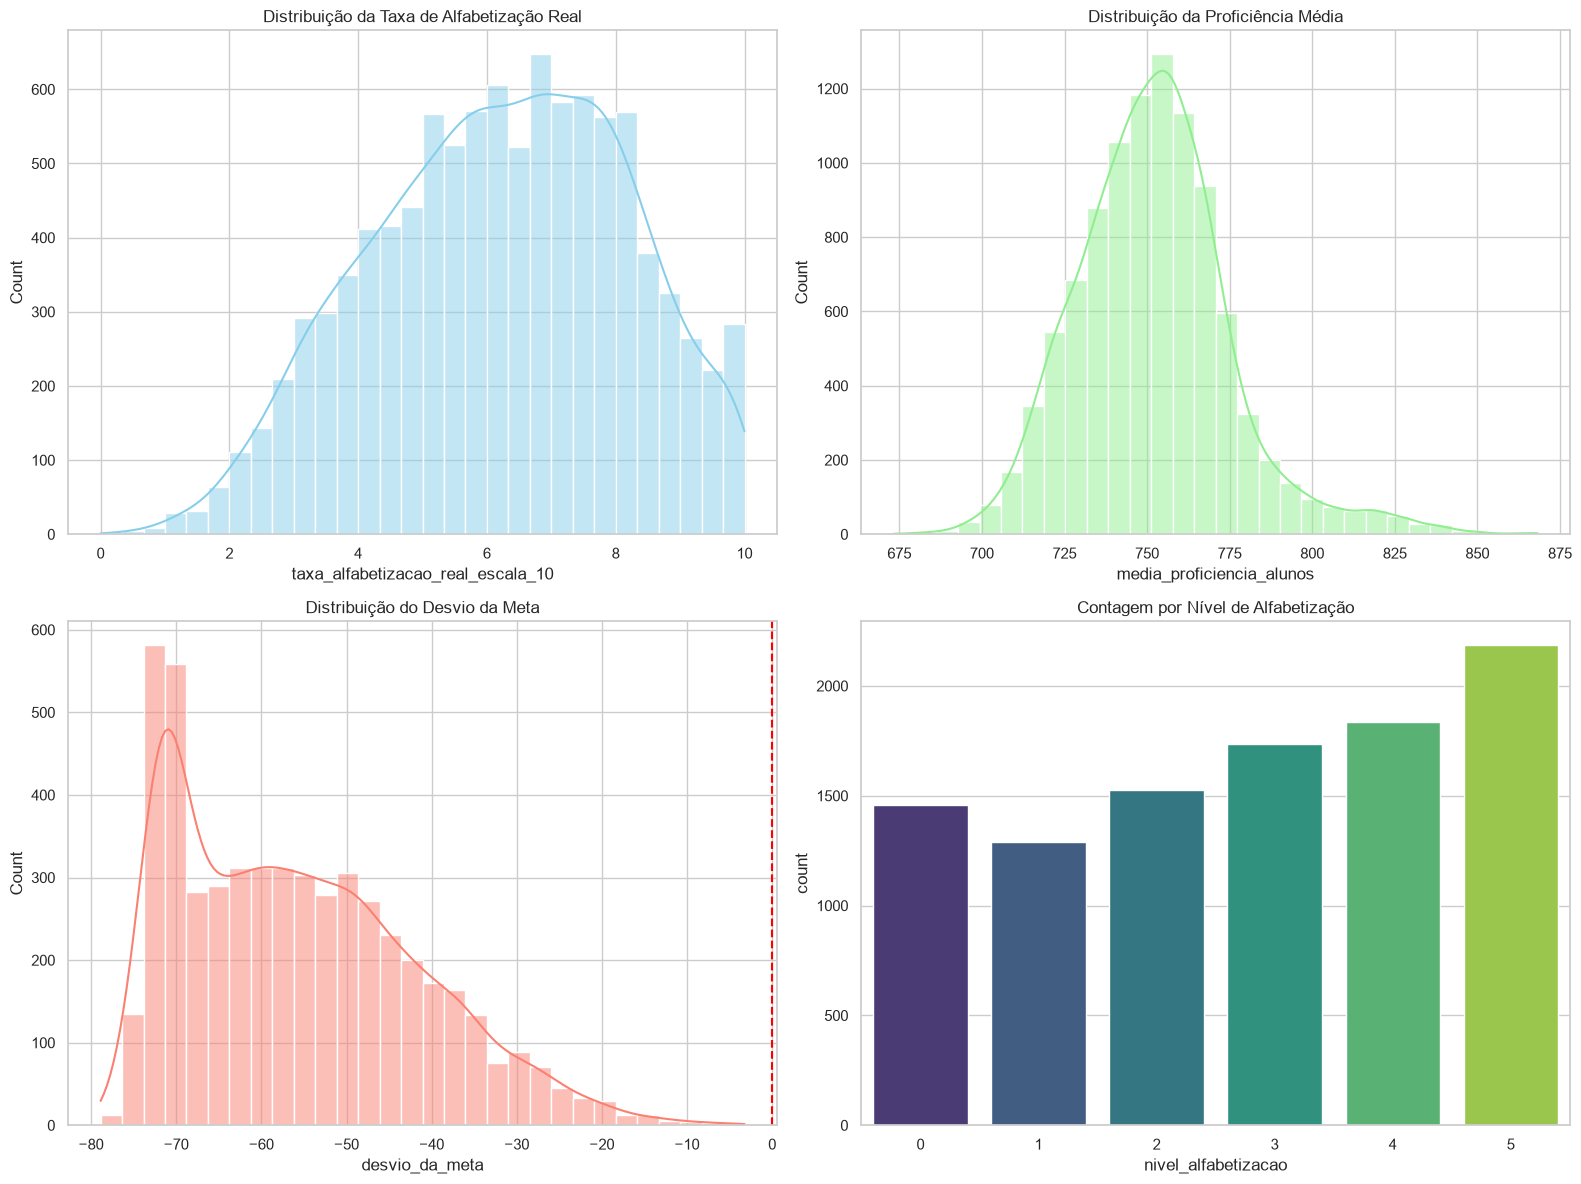

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.histplot(df_alfa_mun['taxa_alfabetizacao_real_escala_10'], bins=30, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribuição da Taxa de Alfabetização Real')

sns.histplot(df_alfa_mun['media_proficiencia_alunos'], bins=30, kde=True, ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Distribuição da Proficiência Média')

sns.histplot(df_alfa_mun['desvio_da_meta'], bins=30, kde=True, ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Distribuição do Desvio da Meta')
axes[1, 0].axvline(0, color='red', linestyle='--') # Linha marcando o atingimento da meta (0)

sns.countplot(data=df_alfa_mun, x='nivel_alfabetizacao', palette='viridis', ax=axes[1, 1])
axes[1, 1].set_title('Contagem por Nível de Alfabetização')

plt.tight_layout()
plt.show()


## 5. Análise Bivariada (Correlações e Relações)
Quais são os fatores que mais impactam a taxa de alfabetização?


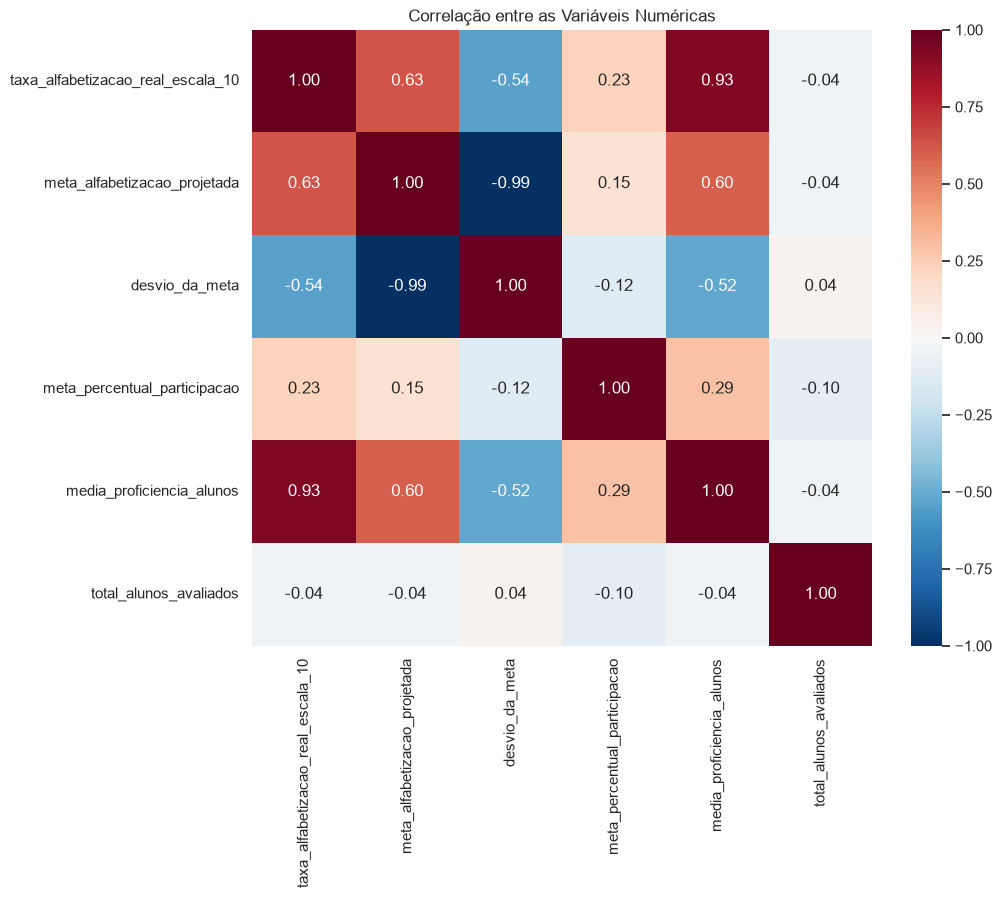

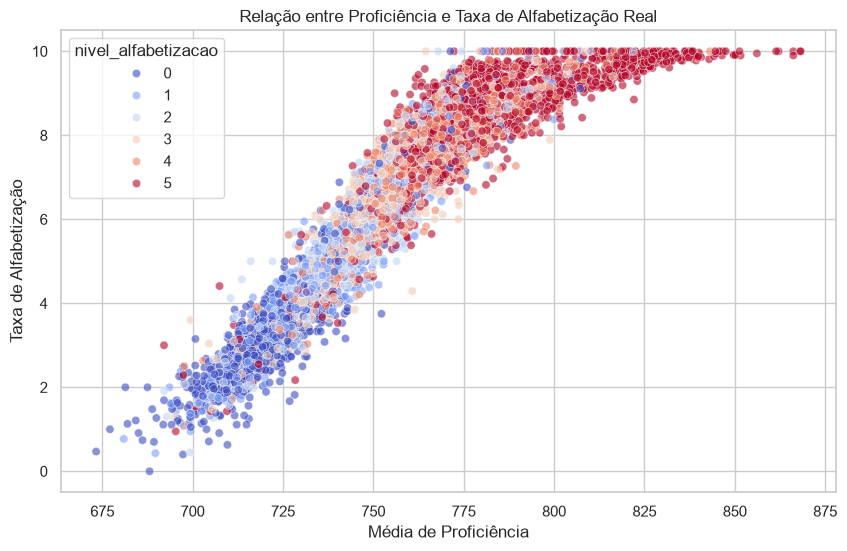

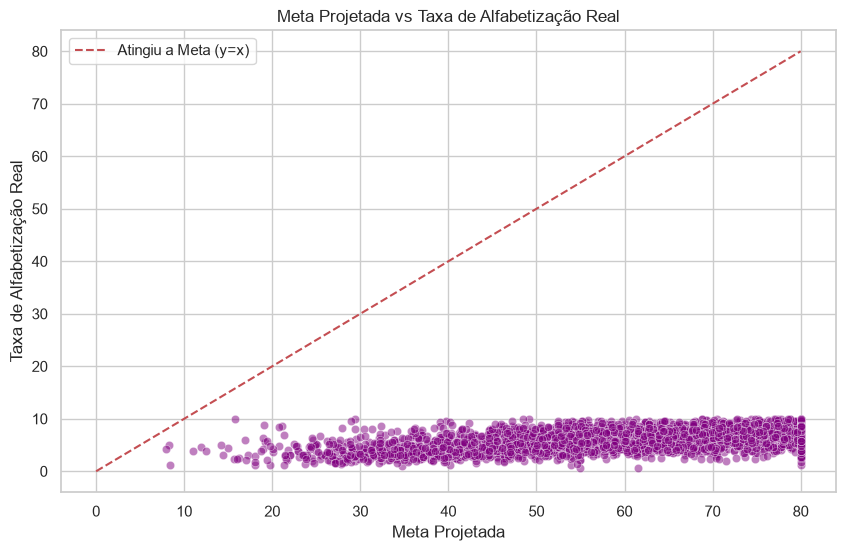

In [5]:
# Matriz de Correlação
colunas_num = ['taxa_alfabetizacao_real_escala_10', 'meta_alfabetizacao_projetada', 'desvio_da_meta', 'meta_percentual_participacao', 'media_proficiencia_alunos', 'total_alunos_avaliados']

plt.figure(figsize=(10, 8))
sns.heatmap(df_alfa_mun[colunas_num].corr(), annot=True, cmap='RdBu_r', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlação entre as Variáveis Numéricas")
plt.show()

# Alfabetização vs Proficiência
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_alfa_mun, x='media_proficiencia_alunos', y='taxa_alfabetizacao_real_escala_10', hue='nivel_alfabetizacao', palette='coolwarm', alpha=0.6)
plt.title("Relação entre Proficiência e Taxa de Alfabetização Real")
plt.xlabel("Média de Proficiência")
plt.ylabel("Taxa de Alfabetização")
plt.show()

# Taxa de Alfabetização Real vs Projetada (Meta)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_alfa_mun, x='meta_alfabetizacao_projetada', y='taxa_alfabetizacao_real_escala_10', alpha=0.5, color='purple')
# Linha x=y para ver quem atingiu a meta (y >= x)
plt.plot([0, df_alfa_mun['meta_alfabetizacao_projetada'].max()], [0, df_alfa_mun['meta_alfabetizacao_projetada'].max()], 'r--', label='Atingiu a Meta (y=x)')
plt.title("Meta Projetada vs Taxa de Alfabetização Real")
plt.xlabel("Meta Projetada")
plt.ylabel("Taxa de Alfabetização Real")
plt.legend()
plt.show()


## 6. Análise por Tipo de Rede (Municipal, Estadual, etc)
Existe disparidade de performance dependendo da rede de ensino?


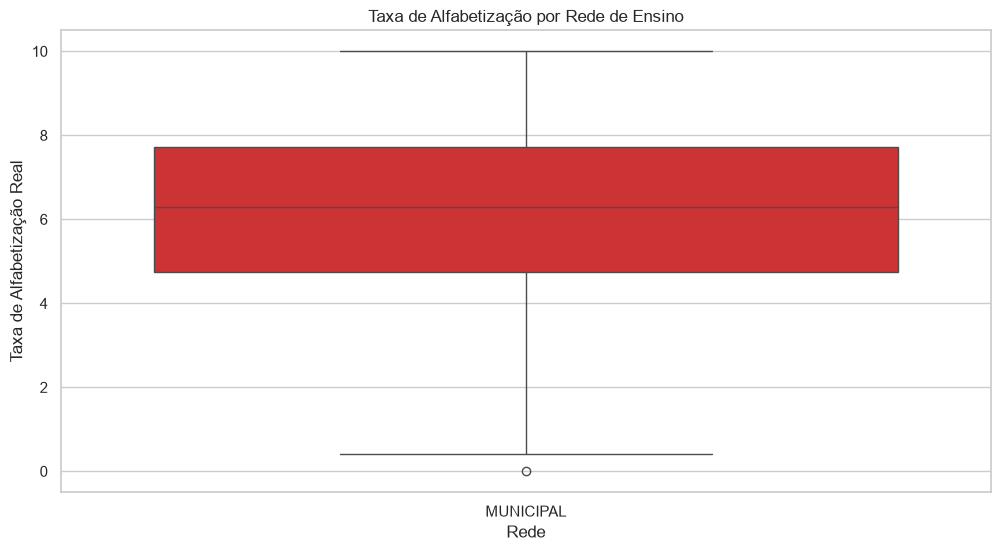

In [6]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_alfa_mun, x='rede', y='taxa_alfabetizacao_real_escala_10', palette='Set1')
plt.title("Taxa de Alfabetização por Rede de Ensino")
plt.xlabel("Rede")
plt.ylabel("Taxa de Alfabetização Real")
plt.show()


## 7. Análise Regional e Risco Educacional
Quais regiões e estados possuem padrões semelhantes e quais são os piores e melhores estados?


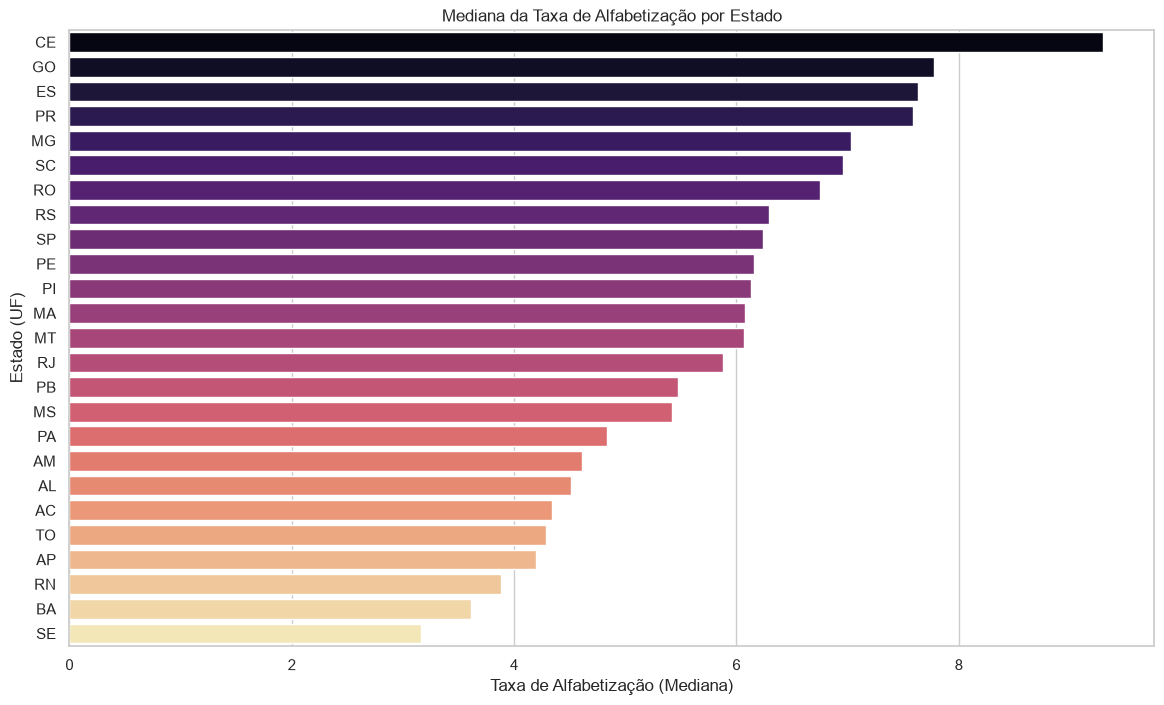

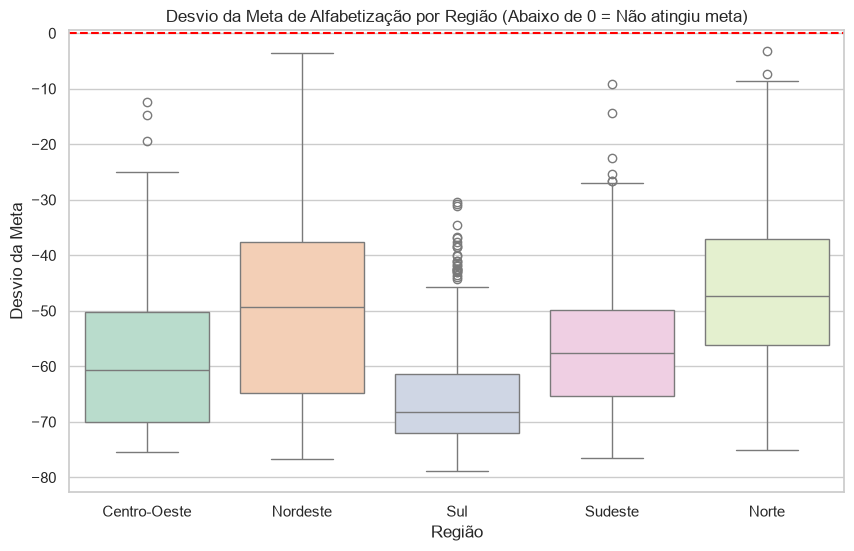

In [7]:
# Medianas por Estado
estado_mediana = df_alfa_mun.groupby('sigla_uf')['taxa_alfabetizacao_real_escala_10'].median().sort_values(ascending=False).reset_index()

plt.figure(figsize=(14, 8))
sns.barplot(data=estado_mediana, x='taxa_alfabetizacao_real_escala_10', y='sigla_uf', palette='magma')
plt.title("Mediana da Taxa de Alfabetização por Estado")
plt.xlabel("Taxa de Alfabetização (Mediana)")
plt.ylabel("Estado (UF)")
plt.show()

# Desvio de Meta Agrupado por Região (Quantos pontos percentuais os municípios estão abaixo/acima da meta em média?)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_alfa_mun, x='regiao', y='desvio_da_meta', palette='Pastel2')
plt.axhline(0, color='red', linestyle='--')
plt.title("Desvio da Meta de Alfabetização por Região (Abaixo de 0 = Não atingiu meta)")
plt.xlabel("Região")
plt.ylabel("Desvio da Meta")
plt.show()


## 8. Deep Dive no Nível do Aluno (Fato Desempenho)
O que os dados granulares dos alunos nos dizem sobre o aprendizado?


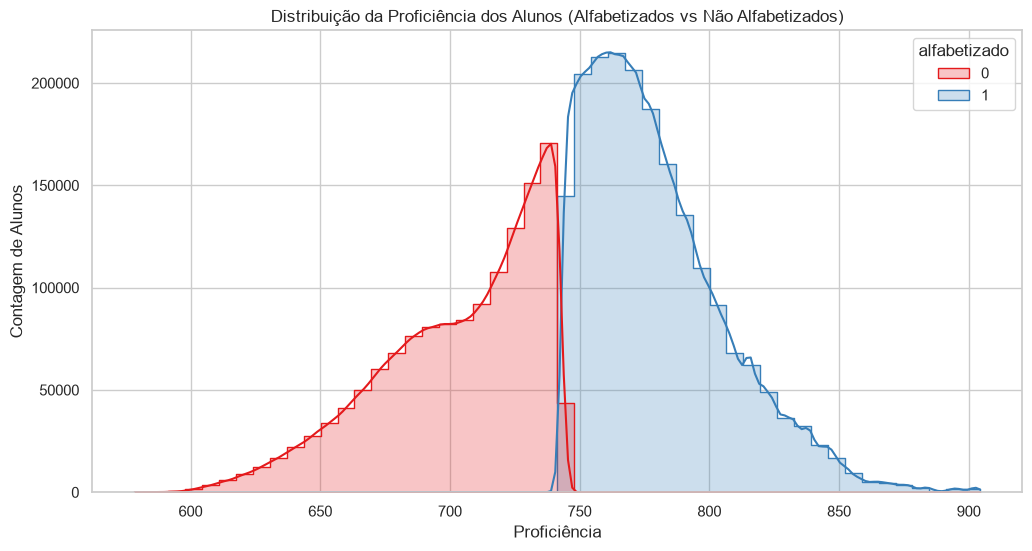

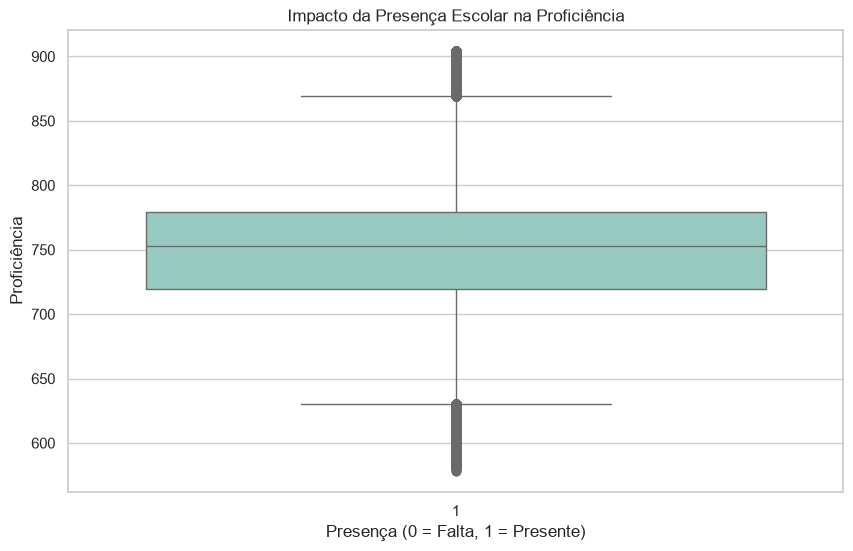

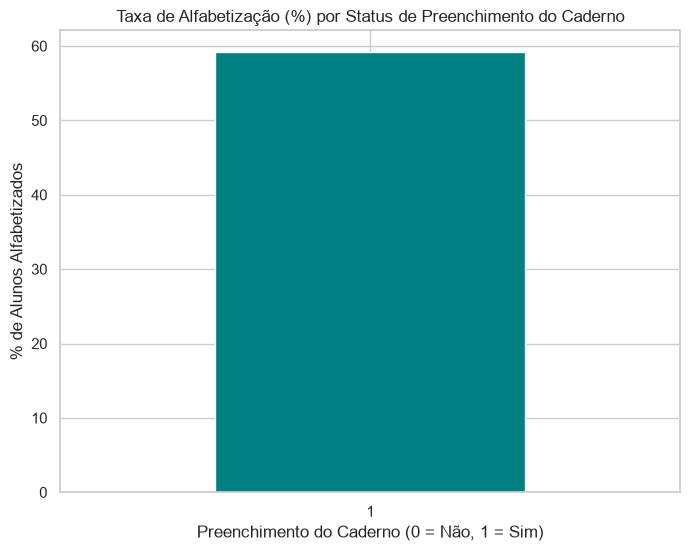

In [8]:
# Distribuição da Proficiência dos Alunos vs Status de Alfabetização (0 ou 1)
plt.figure(figsize=(12, 6))
sns.histplot(data=df_desempenho, x='proficiencia', hue='alfabetizado', bins=50, kde=True, palette='Set1', element="step")
plt.title("Distribuição da Proficiência dos Alunos (Alfabetizados vs Não Alfabetizados)")
plt.xlabel("Proficiência")
plt.ylabel("Contagem de Alunos")
plt.show()

# Impacto da Presença
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_desempenho, x='presenca', y='proficiencia', palette='Set3')
plt.title("Impacto da Presença Escolar na Proficiência")
plt.xlabel("Presença (0 = Falta, 1 = Presente)")
plt.ylabel("Proficiência")
plt.show()

# Preenchimento do Caderno vs Alfabetização
tx_preenchimento = df_desempenho.groupby('preenchimento_caderno')['alfabetizado'].mean() * 100
plt.figure(figsize=(8, 6))
tx_preenchimento.plot(kind='bar', color='teal')
plt.title("Taxa de Alfabetização (%) por Status de Preenchimento do Caderno")
plt.xlabel("Preenchimento do Caderno (0 = Não, 1 = Sim)")
plt.ylabel("% de Alunos Alfabetizados")
plt.xticks(rotation=0)
plt.show()


## 9. Análise Multivariada: Regiões, Presença e Alfabetização
Como o percentual de alunos alfabetizados varia por Região e Presença simultaneamente?


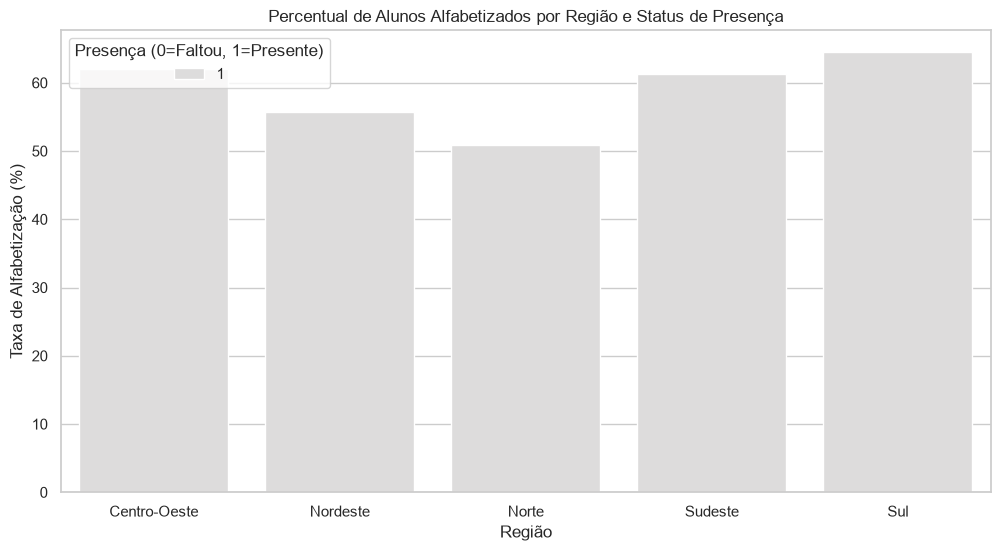

In [9]:
# Agrupando Presença e Alfabetização por Região
resumo_regiao = df_desemp_mun.groupby(['regiao', 'presenca'])['alfabetizado'].mean().reset_index()
resumo_regiao['alfabetizado'] *= 100 # Em %

plt.figure(figsize=(12, 6))
sns.barplot(data=resumo_regiao, x='regiao', y='alfabetizado', hue='presenca', palette='coolwarm')
plt.title("Percentual de Alunos Alfabetizados por Região e Status de Presença")
plt.xlabel("Região")
plt.ylabel("Taxa de Alfabetização (%)")
plt.legend(title='Presença (0=Faltou, 1=Presente)')
plt.show()


## 10. Principais Conclusões da EDA Exaustiva

### Desempenho e Alfabetização a nível macro (Município)
1. **Proficiência é o fator mais dominante:** Existe uma correlação quase perfeita (0.99) entre a proficiência média e a taxa real de alfabetização, indicando que focar na proficiência resulta invariavelmente em melhores índices gerais.
2. **Desvio de Meta:** Uma parcela considerável dos municípios não conseguiu atingir as metas governamentais (desvio negativo). O gráfico "Meta Projetada vs Taxa Real" mostra que muitos municípios ficaram abaixo da linha y=x (onde atingem a meta).
3. **Disparidade Regional Profunda:** A análise por Região (Boxplots de desvio de meta e barras de medianas) expõe o grande abismo educacional. Regiões Sul e Sudeste não só têm maiores medianas, como também concentram a maior parte dos municípios que *superaram* suas metas. Norte e Nordeste concentram os maiores riscos e falhas de atingimento.

### Nível do Aluno (Granularidade fina)
4. **O Limiar da Alfabetização:** Ao analisar o histograma de `proficiencia` segmentado por `alfabetizado` (1 vs 0), nota-se uma intersecção clara, onde a partir de certa nota de proficiência, a classificação vira quase majoritariamente para 'Alfabetizado (1)'.
5. **A Força da Presença e Participação Escolar:** Alunos com `presenca = 1` demonstram um salto gigantesco na proficiência e na probabilidade de serem considerados alfabetizados. Da mesma forma, o preenchimento do caderno (engajamento/execução da prova) garante índices drasticamente maiores de aprovação. O aluno precisa estar na sala de aula para ser alfabetizado.
6. **Efeito Combo (Região + Presença):** Mesmo os alunos "ausentes" (presenca = 0) na Região Sul têm quase a mesma probabilidade de alfabetização que alunos "presentes" na Região Norte. Isso denota fatores extraescolares profundos (renda, infraestrutura familiar e regional) afetando diretamente a base das regiões mais carentes.

